Visualizing the healpix coordinates
==========

In [1]:
using HealpixTransforms
using PyPlot

const HT = HealpixTransforms

HealpixTransforms

Set fourier grid parameters
--------------------------

In [2]:
trn = let nside = 1024 # 512 # 1024 # 2048
    ℍ0(nside, iter=1)
end

HealpixTransforms.ℍ0(1024, 3071, 1)

Make a map of azmuth and polar coordinates
-----------------------------------------

In [3]:
θfull, φfull  = pix(trn)

([0.0007973599634350589, 0.0007973599634350589, 0.0007973599634350589, 0.0007973599634350589, 0.0015947200536071129, 0.0015947200536071129, 0.0015947200536071129, 0.0015947200536071129, 0.0015947200536071129, 0.0015947200536071129  …  3.1399979335361863, 3.1399979335361863, 3.1399979335361863, 3.1399979335361863, 3.1399979335361863, 3.1399979335361863, 3.140795293626358, 3.140795293626358, 3.140795293626358, 3.140795293626358], [0.7853981633974483, 2.356194490192345, 3.9269908169872414, 5.497787143782138, 0.39269908169872414, 1.1780972450961724, 1.9634954084936207, 2.748893571891069, 3.5342917352885173, 4.319689898685965  …  1.9634954084936207, 2.748893571891069, 3.5342917352885173, 4.319689898685965, 5.105088062083414, 5.890486225480862, 0.7853981633974483, 2.356194490192345, 3.9269908169872414, 5.497787143782138])

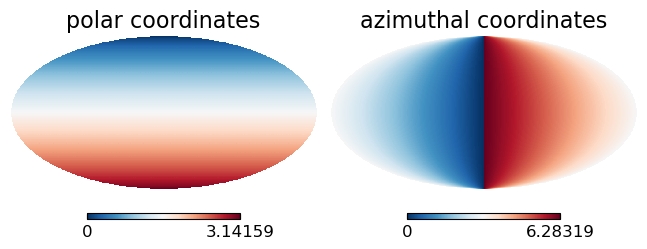

In [4]:
HT.mollview(θfull, sub=(1,2,1), vmin=0, vmax=π, title="polar coordinates")
HT.mollview(φfull, sub=(1,2,2), vmin=0, vmax=2π, title="azimuthal coordinates")
gcf()

From the top plot we see that in mollview the northpole ($\theta = 0$) is shown at the top.

The bottom plot appears counter intuitive at first glance.
Azmimuth $\varphi = 0$ is right at the center of the view,
as expected, but $\varphi \uparrow$ corresponds to moving left rather than
right as would be typical. To understand it I think the best way is to imagine
the view from an observer in the interior of the sphere ... moving "stage right"
from this perspective appears as moving to the left from an observer outside of the sphere.

Exploring rotations in healpix
-----------------------------------------
Rotations are specified by a sequence of three right handed rotation angles in radians.
The convention is z,y,z rotation where:
	- z points to the north pole (i.e. θ=0)
	- y points toward (θ,φ) = (π/2,3π/4) (i.e to the right in mollview)

Lets explore this a bit. First lets look at an initial z rotation by π/4

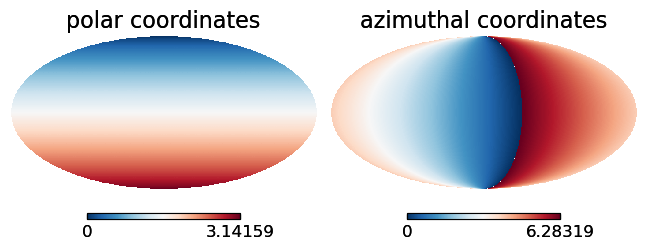

In [5]:
θrot = HT.rotate_map_ZYZ(θfull, π/4, 0, 0)
φrot = HT.rotate_map_ZYZ(φfull, π/4, 0, 0)
HT.mollview(θrot, sub=(1,2,1), vmin=0, vmax=π, title="polar coordinates")
HT.mollview(φrot, sub=(1,2,2), vmin=0, vmax=2π, title="azimuthal coordinates")
gcf()

Now set initial z rotation to zero, but the y rotation to π/4

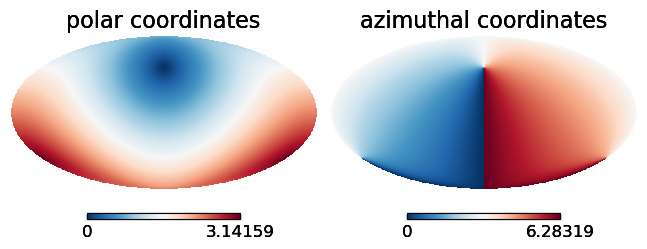

In [6]:
θrot = HT.rotate_map_ZYZ(θfull, 0, π/4, 0)
φrot = HT.rotate_map_ZYZ(φfull, 0, π/4, 0)
HT.mollview(θrot, sub=(1,2,1), vmin=0, vmax=π, title="polar coordinates")
HT.mollview(φrot, sub=(1,2,2), vmin=0, vmax=2π, title="azimuthal coordinates")
gcf()

This can be imagined by grabbing (with your right hand) a vector emitting from the right
side of mollview. Then twisting by π/4 in the direction of your fingers.

Just to double check our understanding, if we to a zyz rotation of (0,-π/4,0) the south pole
should move directly up the center of view, yeilding the red hot spot moving up in the polar coordinate map.

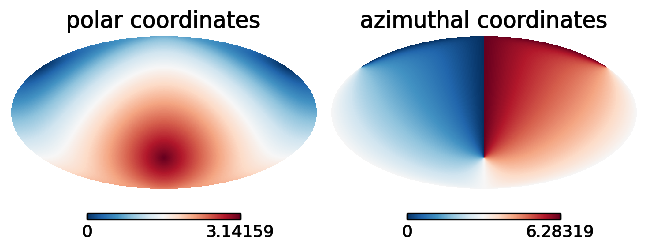

In [7]:
θrot = HT.rotate_map_ZYZ(θfull, 0, -π/4, 0)
φrot = HT.rotate_map_ZYZ(φfull, 0, -π/4, 0)
HT.mollview(θrot, sub=(1,2,1), vmin=0, vmax=π, title="polar coordinates")
HT.mollview(φrot, sub=(1,2,2), vmin=0, vmax=2π, title="azimuthal coordinates")
gcf()

Now we can move the red hot spot in the polar map, to "stage right" by a final z rotation
which is negative.

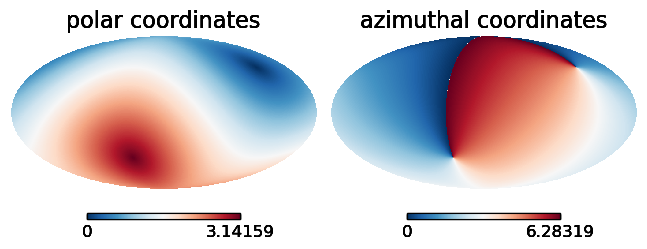

In [8]:
θrot = HT.rotate_map_ZYZ(θfull, 0, -π/4, -π/4)
φrot = HT.rotate_map_ZYZ(φfull, 0, -π/4, -π/4)
HT.mollview(θrot, sub=(1,2,1), vmin=0, vmax=π, title="polar coordinates")
HT.mollview(φrot, sub=(1,2,2), vmin=0, vmax=2π, title="azimuthal coordinates")
gcf()

Extracting the equitorial belt
-----------------------------------------
HealpixTransforms.jl has functions for extracting the equitorial belt,
organized in a retangular array with polar angle running down the rows
(increasing row index -> increasing polar angle) and
azimuthal running across the columnes (increasing column index -> increasing azimuth)

In [9]:
eqθ = HT.eqbelt(θfull)
eqφ = HT.eqbelt(φfull)

2047×4096 Array{Float64,2}:
 -4.44089e-16   0.00153398  0.00306796  …  6.27705  6.27858  6.28012  6.28165
  3.14159      -0.856873    0.477994       6.0307   6.60366  5.80519  7.14006
 -4.44089e-16   0.00153398  0.00306796     6.27705  6.27858  6.28012  6.28165
  3.14159      -0.856873    0.477994       6.0307   6.60366  5.80519  7.14006
 -4.44089e-16   0.00153398  0.00306796     6.27705  6.27858  6.28012  6.28165
  3.14159      -0.856873    0.477994    …  6.0307   6.60366  5.80519  7.14006
 -4.44089e-16   0.00153398  0.00306796     6.27705  6.27858  6.28012  6.28165
  3.14159      -0.856873    0.477994       6.0307   6.60366  5.80519  7.14006
 -4.44089e-16   0.00153398  0.00306796     6.27705  6.27858  6.28012  6.28165
  3.14159      -0.856873    0.477994       6.0307   6.60366  5.80519  7.14006
  ⋮                                     ⋱                             ⋮
 -4.44089e-16   0.00153398  0.00306796     6.27705  6.27858  6.28012  6.28165
  3.14159      -0.856873    0.477994      

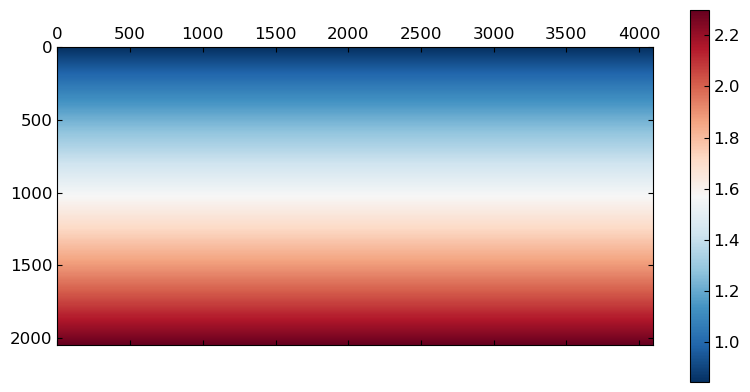

In [10]:
eqθ |> matshow; colorbar(); gcf()

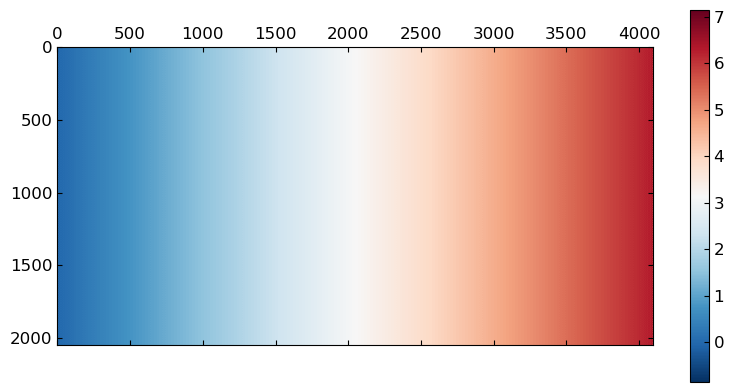

In [11]:
eqφ |> matshow; colorbar(); gcf()